<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/group_exercises/exercise_1/Group_Exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 2 – Data Preprocessing on a Real Dataset
# Group Exercise 1

Dataset **"House Prices - Advanced Regression Techniques"**

The dataset contains properties with various environmental variables.

Source:
https://www.kaggle.com/datasets/rishitaverma02/house-prices-advanced-regression-techniques

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso

**1. Handling Missing Values**

Identify missing values

Apply appropriate imputation methods (mean, median, mode, or justified alternative)

In [18]:
# Load Kaggle dataset
df = pd.read_csv('https://raw.githubusercontent.com/k-git-25/week_2/refs/heads/main/train_house.csv') # RAW Data from GitHub
#house_data.head()
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Shape: (1460, 81)

Missing values:
PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64


In [19]:
from pandas.core.arrays import categorical
numerical_columns = df.select_dtypes(include='number').columns
#print(numerical_columns)
categorical_columns = df.select_dtypes(exclude='number').columns
#print(categorical_columns)

# numerical imputation
imput_median = SimpleImputer(strategy="median")
imput_mean = SimpleImputer(strategy="mean")

for feature in numerical_columns:

  if df[feature].isnull().sum().mean() == 0:  # if none are missing
    continue                                  # continue in the loop

  print(f"Numerical Feature {feature} missing: {df[feature].isnull().sum()}")
  if df[feature].skew() > 1 or df[feature].skew() < -1:
    # imput_median
    df[[feature]] = imput_median.fit_transform(df[[feature]])
    print(f"Numerical Feature {feature} imputed {imput_median.strategy}")
  else:
    # imput_mean
    df[[feature]] = imput_mean.fit_transform(df[[feature]])
    print(f"Numerical Feature {feature} imputed {imput_mean.strategy}")


# categorical imputation
imputer_mode = SimpleImputer(strategy="most_frequent")

for feature in categorical_columns:
  if df[feature].isnull().sum() == 0:
    continue

  print(f"Categorical Feature {feature} missing: {df[feature].isnull().sum()}")
  df[[feature]] = imputer_mode.fit_transform(df[[feature]])
  print(f"Categorical Feature {feature} imputed {imputer_mode.strategy}")

# Adjusted features
print("\nAdjusted features:")
print(df.isnull().sum().sort_values(ascending=False))


Numerical Feature LotFrontage missing: 259
Numerical Feature LotFrontage imputed median
Numerical Feature MasVnrArea missing: 8
Numerical Feature MasVnrArea imputed median
Numerical Feature GarageYrBlt missing: 81
Numerical Feature GarageYrBlt imputed mean
Categorical Feature Alley missing: 1369
Categorical Feature Alley imputed most_frequent
Categorical Feature MasVnrType missing: 872
Categorical Feature MasVnrType imputed most_frequent
Categorical Feature BsmtQual missing: 37
Categorical Feature BsmtQual imputed most_frequent
Categorical Feature BsmtCond missing: 37
Categorical Feature BsmtCond imputed most_frequent
Categorical Feature BsmtExposure missing: 38
Categorical Feature BsmtExposure imputed most_frequent
Categorical Feature BsmtFinType1 missing: 37
Categorical Feature BsmtFinType1 imputed most_frequent
Categorical Feature BsmtFinType2 missing: 38
Categorical Feature BsmtFinType2 imputed most_frequent
Categorical Feature Electrical missing: 1
Categorical Feature Electrical i

**2. Scaling Numerical Features**

Apply Z-score standardization

Apply Min–Max normalization

Briefly explain the difference

In [20]:
features = ['YearBuilt', 'SalePrice']
X = df[features].copy()

# Standardisation Z-Score
z_scaler = StandardScaler()
z_X = z_scaler.fit_transform(X)
z_X = pd.DataFrame(z_X, columns=[f + '_z' for f in features])

# Normalisation (Min Max)
mm_scaler = MinMaxScaler()
mm_X = mm_scaler.fit_transform(X)
mm_X = pd.DataFrame(mm_X, columns=[f + '_mm' for f in features])

# compared
comparsion = pd.concat([X, z_X, mm_X], axis=1)
print(comparsion.head())

   YearBuilt  SalePrice  YearBuilt_z  SalePrice_z  YearBuilt_mm  SalePrice_mm
0       2003     208500     1.050994     0.347273      0.949275      0.241078
1       1976     181500     0.156734     0.007288      0.753623      0.203583
2       2001     223500     0.984752     0.536154      0.934783      0.261908
3       1915     140000    -1.863632    -0.515281      0.311594      0.145952
4       2000     250000     0.951632     0.869843      0.927536      0.298709


Explanation

Z-score is preferable when data is approximately symmetrical/normally distributed. Each variable is given equal weighting. The Z-score is better suited to dealing with outliers. Min-max scaling, on the other hand, is useful when dealing with limited ranges, e.g. 0–1, i.e. features are required within strict limits.

**3. Handling Noise**

Choose one numerical feature

Inject artificial noise

Apply a smoothing technique (e.g. rolling mean)

Show before vs after results

In [21]:
# numerical feature: Sales price
signal = df['SalePrice'].copy()

# Add artificial noise (small random variations) to this feature. "Reproducible"
np.random.seed(42)
noise = np.random.normal(loc=0, scale=1, size=len(signal)) # loc: mean, std (spread),

# Apply a simple noise-handling technique, Smoothing by aggregation
signal_noisy = signal + noise
signal_smoothed = signal_noisy.rolling(window=4, min_periods=1).mean() # Slight smoothing and without NaN (1)

comparison_df = pd.DataFrame({
  'Orig. Signal': signal,
  'Noisy': signal_noisy,
  'Smoothed': signal_smoothed

})

print(comparison_df.head(10))

   Orig. Signal          Noisy       Smoothed
0        208500  208500.496714  208500.496714
1        181500  181499.861736  195000.179225
2        223500  223500.647689  204500.335379
3        140000  140001.523030  188375.632292
4        250000  249999.765847  198750.449575
5        143000  142999.765863  189125.425607
6        307000  307001.579213  210000.658488
7        200000  200000.767435  225000.469589
8        129900  129899.530526  194975.410759
9        118000  118000.542560  188725.604933


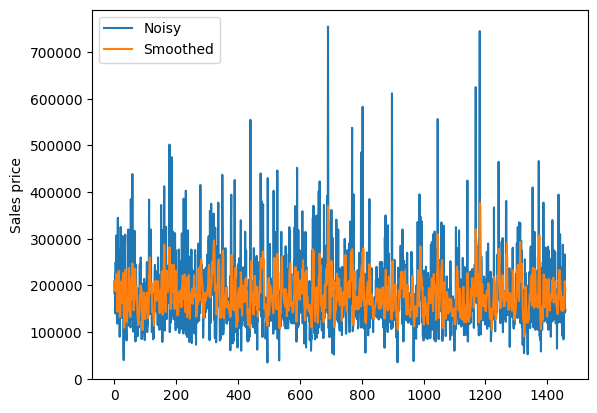

In [22]:
plt.plot(signal_noisy, label='Noisy')
plt.plot(signal_smoothed, label='Smoothed')
plt.ylabel('Sales price')
plt.legend()
plt.show()

**4. Handling Outliers**

Detect outliers using Z-score

Handle them via removal or transformation

Justify your approach

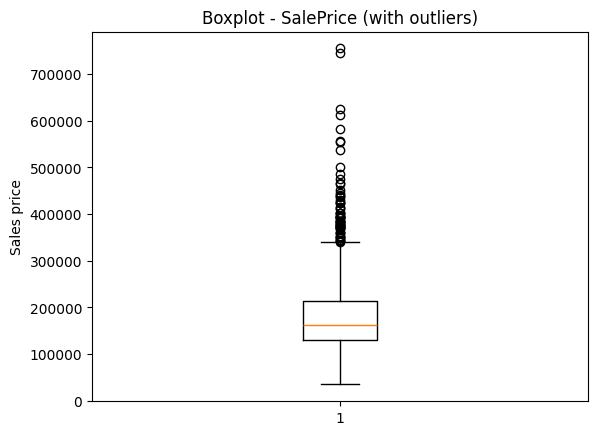

In [23]:
plt.boxplot(df['SalePrice'])
plt.title('Boxplot - SalePrice (with outliers)')
plt.ylabel('Sales price')
plt.show()

In [24]:
df['SalePrice_z_score'] = zscore(df['SalePrice'])

outliers = df[np.abs(df['SalePrice_z_score']) > 3]

print("Outliers:", len(outliers))

Outliers: 22


## Show after

Deleted outliers: 22


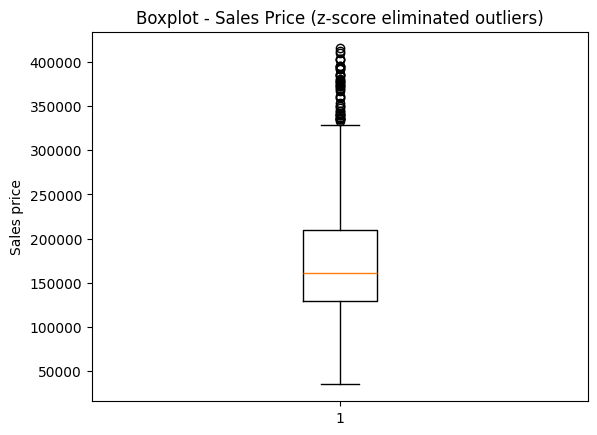

In [25]:
# Delete outliers using z-score

threshold = 3 # Outliers (> 99,7% der normal distribution)

df_no_outliers = df[np.abs(df['SalePrice_z_score']) <= threshold]

print("Deleted outliers:", len(df) - len(df_no_outliers))

plt.boxplot(df_no_outliers['SalePrice'])
plt.title('Boxplot - Sales Price (z-score eliminated outliers)')
plt.ylabel('Sales price')
plt.show() # See circles (outliers)

**5. Feature Selection**

Apply at least one of the following:

Filter method (e.g. correlation, mutual information)

Wrapper method (e.g. RFE)

Embedded method (e.g. Lasso)

In [35]:
# Lasso method

# Ensuring that there are no missing values
print(df.isnull().sum().sort_values(ascending=False))

X = df[['YearBuilt', 'LotArea']]          # influencing factors (if necessary further scaling required)
y = df['SalePrice']                       # target value

lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X, y)

pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_})  #  If coefficient is higher, feature increases price



Id                   0
MSSubClass           0
MSZoning             0
LotFrontage          0
LotArea              0
                    ..
YrSold               0
SaleType             0
SaleCondition        0
SalePrice            0
SalePrice_z_score    0
Length: 82, dtype: int64


,Feature,Coefficient
0,YearBuilt,1365.776044
1,LotArea,2.041172
